## Regression
Car price prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Preperation

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/refs/heads/master/chapter-02-car-price/data.csv")
len(df)

11914

In [3]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [4]:
string = list(df.dtypes[df.dtypes == "object"].index)
string

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [5]:
for col in string:
    df[col] = df[col].str.lower().str.replace(" ", "_")

In [6]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


### Exploratory Data Analysis

In [7]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
['bmw' 'audi' 'fiat' 'mercedes-benz' 'chrysler']
48

model
['1_series_m' '1_series' '100' '124_spider' '190-class']
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
['premium_unleaded_(required)' 'regular_unleaded'
 'premium_unleaded_(recommended)' 'flex-fuel_(unleaded/e85)' 'diesel']
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
['manual' 'automatic' 'automated_manual' 'direct_drive' 'unknown']
5

driven_wheels
['rear_wheel_drive' 'front_wheel_drive' 'all_wheel_drive'
 'four_wheel_drive']
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
['factory_tuner,luxury,high-performance' 'luxury,performance'
 'luxury,high-performance' 'luxury' 'performance']
71

vehicle_size
['compact' 'midsize' 'large']
3

vehicle_style
['coupe' 'convertible' 'sedan' 'wagon' '4dr_hatchback']
16

highway_mpg
[26 28 27 25 24]
59

city_mpg
[19 20 18 17 16]
69

popularity
[3916 3105  819  617 1013]
48

msrp
[46135 40650 36350 29450 345

In [8]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


Price Distribution

<Axes: xlabel='msrp', ylabel='Count'>

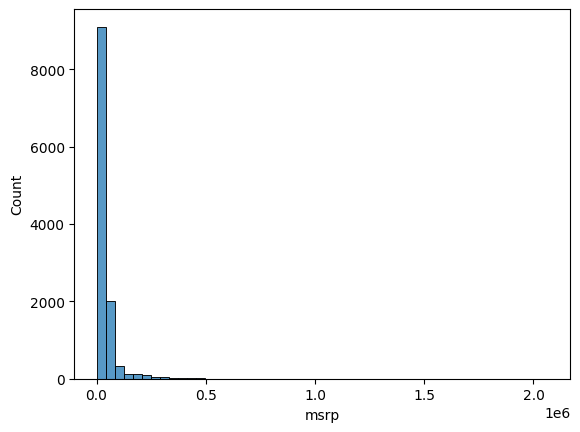

In [9]:
sns.histplot(df.msrp, bins=50) # We have a long tail situation which isn't ideal for the model

<Axes: xlabel='msrp', ylabel='Count'>

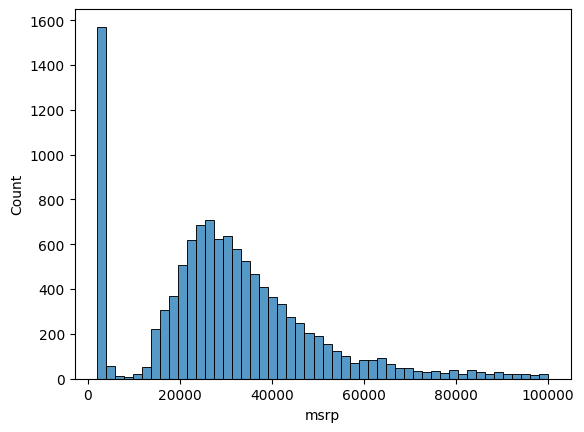

In [10]:
sns.histplot(df.msrp[df.msrp < 100000], bins=50)  # This however is still not ideal for our model

In [11]:
np.log1p([0,1,100,1000,10000]) # We apply log distribution to get more compact values (get rid of the long tail)

array([0.        , 0.69314718, 4.61512052, 6.90875478, 9.21044037])

<Axes: xlabel='msrp', ylabel='Count'>

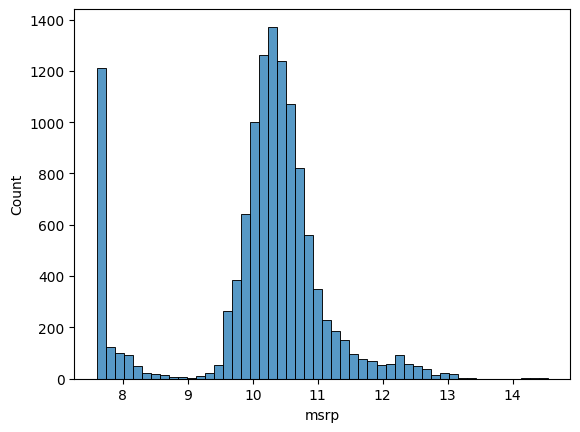

In [12]:
msrp_log = np.log1p(df.msrp)    # We now have a normal distribution which is ideal for our model
sns.histplot(msrp_log, bins=50)

Missing Values

In [13]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

### Setting up the validation framework 
Splitting data into training, validation & testing sets

In [14]:
n = len(df)
val = int(n*0.2)
test = int(n*0.2)
train = n-val-test
n, train, val, test

(11914, 7150, 2382, 2382)

In [15]:
df_train = df.iloc[:train]
df_val = df.iloc[train:train+val]
df_test = df.iloc[train+val:]

In [16]:
seq = np.arange(n) # Generate a sequence of values

In [17]:
seq = np.arange(n) # Generate a sequence of values
np.random.shuffle(seq) # Shuffling the dataset

In [18]:
np.random.seed()  # Ensure reshuffled data does not keep changing
np.random.shuffle(seq) # Shuffling the dataset

In [19]:
df_train = df.iloc[seq[:train]]
df_val = df.iloc[seq[train:train+val]]
df_test = df.iloc[seq[train+val:]]


In [20]:
len(df_train), len(df_val), len(df_test)

(7150, 2382, 2382)

In [21]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [22]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [23]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

### Linear Regression 

In [24]:
df_train.iloc[98]

make                               gmc
model                          terrain
year                              2015
engine_fuel_type      regular_unleaded
engine_hp                        182.0
engine_cylinders                   4.0
transmission_type            automatic
driven_wheels        front_wheel_drive
number_of_doors                    4.0
market_category              crossover
vehicle_size                   compact
vehicle_style                  4dr_suv
highway_mpg                         32
city_mpg                            22
popularity                         549
Name: 98, dtype: object

In [25]:
xi = [400.0, 18, 1715] # Using engine_hp, city_mpg & popularity to predict car price

w0 = 5.5     # Assigning weights to each feature
w = [0.01, 0.05, 0.001]

In [26]:
def linear_regression(xi):
    n = len(xi)
    
    pred = w0
    
    for i in range(n):
        pred = pred + w[i] * xi[i]
        
    return pred

In [27]:
p=linear_regression(xi)
p

12.115

In [28]:
np.exp(p)

np.float64(182590.27733054178)

### Linear Regression- Vector Form

In [29]:
def dot(xi, w):
    n = len(xi)
    
    result = w0
    
    for i in range(n):
        result = result + w[i] * xi[i]
        
    return result

In [30]:
dot(xi, w)

12.115

In [31]:
np.exp(12.115)

np.float64(182590.27733054178)

In [32]:
def linear_regression(xi):    
    return w0+ dot(xi, w)

In [33]:
w_n = [w0] + w

In [34]:
w_n

[5.5, 0.01, 0.05, 0.001]

In [35]:
def linear_regression(xi):  
    xi = [1] + xi 
    return dot(xi, w_n)

In [36]:
linear_regression(xi)

17.615000000000002

In [37]:
w0 = 5.5
w = [0.01, 0.05, 0.001]
w_n = [w0] + w

In [38]:
x1 = [1, 400, 18, 1715]
x2 = [1, 365, 21, 5657]
x5 = [1, 389, 31, 2657]
xn = [1, 540, 32, 1918]

In [39]:
x = [x1, x2, x5, xn]
x = np.array(x)

In [40]:
def linear_regression(x):
    return x.dot(w_n)

In [41]:
linear_regression(x)

array([12.115, 15.857, 13.597, 14.418])

### Training Linear Regression Model

In [42]:

def train_linear_regression(x, y):
    """
    Train a linear regression model.

    Parameters:
        x (numpy.ndarray): The input feature matrix (without the intercept column).
        y (numpy.ndarray): The target variable.

    Returns:
        tuple: A tuple containing the intercept (w0) and coefficients (w).
    """

    # Convert inputs to numpy arrays if they aren't already
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    
    # Add a column of ones for the intercept term
    ones = np.ones(x.shape[0])
    x = np.column_stack([ones, x])

    # Compute XTX
    XTX = x.T @ x

    # Check if XTX is invertible
    if np.linalg.det(XTX) == 0:
        raise ValueError("Matrix XTX is singular and cannot be inverted.")
    
    # Compute the inverse of XTX
    XTX_inv = np.linalg.inv(XTX)

    # Compute weights
    weight = XTX_inv @ x.T @ y
    w0 = weight[0]
    w = weight[1:]

    return w0, w

# Example usage
if __name__ == "__main__":
    x = np.array([
        [400, 18, 1715],
        [365, 21, 5657],
        [389, 31, 2657],
        [540, 32, 1918],
        [410, 28, 1215],
        [465, 31, 5057],
        [389, 34, 1657],
        [640, 28, 3918]
    ])
    
    y = np.array([150, 200, 240, 147, 250, 100, 157, 230])

    try:
        w0, w = train_linear_regression(x, y)
        print(f"Intercept (w0): {w0}")
        print(f"Coefficients (w): {w}")
    except ValueError as e:
        print(e)


Intercept (w0): 223.70993020678412
Coefficients (w): [ 0.03231938 -1.26969674 -0.00625461]


### Car Price Baseline Model

In [43]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='object')

In [44]:
df_train.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [45]:
base = ['engine_hp', 'engine_cylinders', 'number_of_doors']

In [46]:
X_train = df_train[base].values
X_train = df_train[base].fillna(0).values

In [47]:
train_linear_regression(X_train, y_train)

(np.float64(8.32297939138261), array([ 0.00984564, -0.24063336,  0.20275765]))

In [48]:
w0, w = train_linear_regression(X_train, y_train)

In [49]:
y_pred = w0 + X_train.dot(w)
y_pred

array([ 9.31474117,  9.59909501, 10.19217341, ...,  9.81219415,
        9.26551295, 13.51015565])

<Axes: ylabel='Count'>

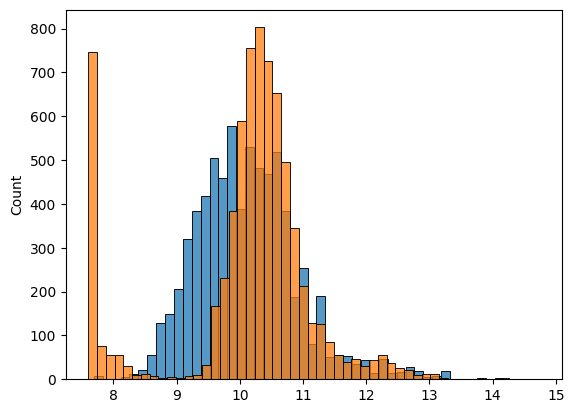

In [50]:
sns.histplot(y_pred,  bins =50)
sns.histplot(y_train, bins =50)

In [51]:
def rmse(y, y_pred):
    error = y-y_pred
    se = error**2
    mse = se.mean()
    return np.sqrt(mse)
    

In [52]:
rmse(y_train, y_pred)

np.float64(0.7622190097752878)

### Model Validation

In [53]:
base = ['engine_hp', 'engine_cylinders', 'number_of_doors']
X_train = df_train[base].values
X_train = df_train[base].fillna(0).values
train_linear_regression(X_train, y_train)
w0, w = train_linear_regression(X_train, y_train)
y_pred = w0 + X_train.dot(w)                                       

In [54]:
def model_val(df):
    df_n = df[base]
    df_n = df.fillna(0)
    X = df_n.values
    return X                               

In [55]:
X_train = model_val(df_train)
w0, w = train_linear_regression(X_train, y_train)
X_val = model_val(df_val)

y_pred = w0 + X_val.dot(w)   

ValueError: could not convert string to float: 'chevrolet'

In [ ]:
rmse(y_val, y_pred)